# 3. NLP evaluation and publication-quality research figures

This notebook develops Matplotlib patterns for annotation studies, classification experiments, semantic-relatedness tasks, and research reporting.

## Learning objectives

You will learn to plot:

- class and annotation distributions;
- inter-annotator confusion;
- normalized confusion matrices;
- per-class precision, recall, and F1;
- model comparisons with uncertainty;
- learning curves;
- threshold trade-offs;
- calibration and residual diagnostics;
- semantic-relatedness predictions;
- 2-D embedding projections;
- publication-ready multi-panel figures.

> All numbers are synthetic. Replace them with results produced by your own pipeline.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RNG = np.random.default_rng(2026)

plt.rcParams.update({
    "figure.figsize": (8.5, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

print("Matplotlib:", matplotlib.__version__)

Matplotlib: 3.10.8


## 1. Annotation coverage and missingness

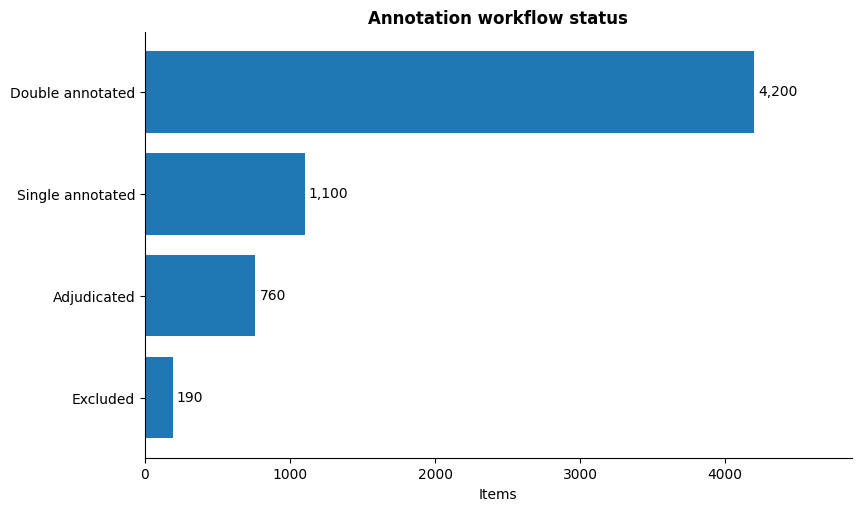

In [2]:
annotation_status = pd.Series({
    "Double annotated": 4200,
    "Single annotated": 1100,
    "Adjudicated": 760,
    "Excluded": 190,
}).sort_values()

fig, ax = plt.subplots(layout="constrained")
bars = ax.barh(annotation_status.index, annotation_status.values)
ax.bar_label(bars, padding=3, fmt="{:,.0f}")
ax.set(
    title="Annotation workflow status",
    xlabel="Items",
    ylabel="",
)
ax.set_xlim(0, annotation_status.max() * 1.16)
plt.show()

## 2. Inter-annotator confusion

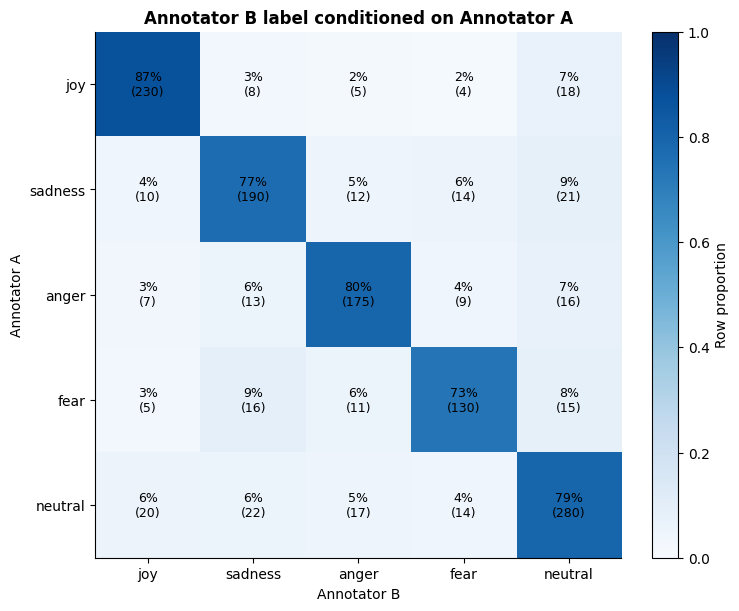

In [3]:
labels = ["joy", "sadness", "anger", "fear", "neutral"]
agreement_counts = np.array([
    [230,  8,  5,  4, 18],
    [ 10, 190, 12, 14, 21],
    [  7, 13, 175,  9, 16],
    [  5, 16, 11, 130, 15],
    [ 20, 22, 17, 14, 280],
])

row_pct = agreement_counts / agreement_counts.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.5, 6), layout="constrained")
im = ax.imshow(row_pct, cmap="Blues", vmin=0, vmax=1)
ax.set(
    title="Annotator B label conditioned on Annotator A",
    xlabel="Annotator B",
    ylabel="Annotator A",
    xticks=np.arange(len(labels)),
    xticklabels=labels,
    yticks=np.arange(len(labels)),
    yticklabels=labels,
)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{row_pct[i, j]:.0%}\n({agreement_counts[i, j]})",
                ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Row proportion")
plt.show()

A confusion heatmap reveals which labels annotators systematically conflate.  
It complements—rather than replaces—agreement coefficients such as Cohen's kappa or Krippendorff's alpha.

## 3. Classification confusion matrix

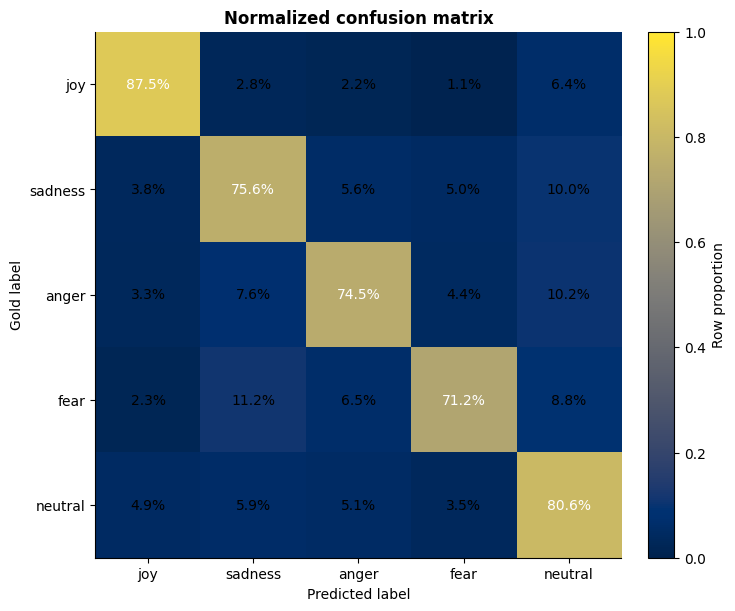

In [4]:
class_names = ["joy", "sadness", "anger", "fear", "neutral"]
cm = np.array([
    [315, 10,  8,  4, 23],
    [ 12, 242, 18, 16, 32],
    [  9, 21, 205, 12, 28],
    [  5, 24, 14, 153, 19],
    [ 25, 30, 26, 18, 410],
])

def plot_confusion_matrix(cm: np.ndarray, labels: list[str], *, normalize: bool = True):
    matrix = cm.astype(float)
    if normalize:
        denominator = matrix.sum(axis=1, keepdims=True)
        matrix = np.divide(matrix, denominator, where=denominator != 0)

    fig, ax = plt.subplots(figsize=(7.2, 6), layout="constrained")
    im = ax.imshow(matrix, cmap="cividis", vmin=0, vmax=1 if normalize else None)
    ax.set(
        title="Normalized confusion matrix" if normalize else "Confusion matrix",
        xlabel="Predicted label",
        ylabel="Gold label",
        xticks=np.arange(len(labels)),
        xticklabels=labels,
        yticks=np.arange(len(labels)),
        yticklabels=labels,
    )

    threshold = matrix.max() / 2
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text = f"{matrix[i, j]:.1%}" if normalize else f"{int(matrix[i, j])}"
            ax.text(
                j, i, text,
                ha="center", va="center",
                color="white" if matrix[i, j] > threshold else "black",
            )

    fig.colorbar(im, ax=ax, label="Row proportion" if normalize else "Count")
    return fig, ax


fig, ax = plot_confusion_matrix(cm, class_names, normalize=True)
plt.show()

State the normalization direction. Row normalization answers: “For each gold class, where did the model place its predictions?”

## 4. Per-class precision, recall, and F1

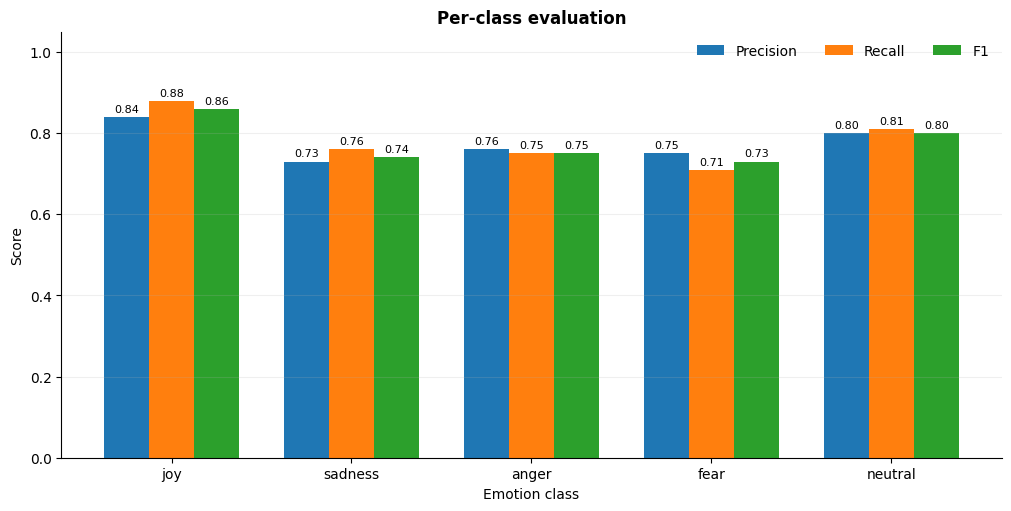

In [5]:
metrics = pd.DataFrame({
    "class": class_names,
    "precision": [0.84, 0.73, 0.76, 0.75, 0.80],
    "recall":    [0.88, 0.76, 0.75, 0.71, 0.81],
    "f1":        [0.86, 0.74, 0.75, 0.73, 0.80],
}).set_index("class")

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
for offset, metric in zip([-width, 0, width], ["precision", "recall", "f1"]):
    bars = ax.bar(x + offset, metrics[metric], width, label=metric.capitalize())
    ax.bar_label(bars, padding=2, fmt="%.2f", fontsize=8)

ax.set(
    title="Per-class evaluation",
    xlabel="Emotion class",
    ylabel="Score",
    xticks=x,
    xticklabels=metrics.index,
    ylim=(0, 1.05),
)
ax.legend(ncols=3)
ax.grid(axis="y", alpha=0.2)
plt.show()

Macro averages should be accompanied by per-class scores when minority classes are substantively important.

## 5. Comparing models with uncertainty

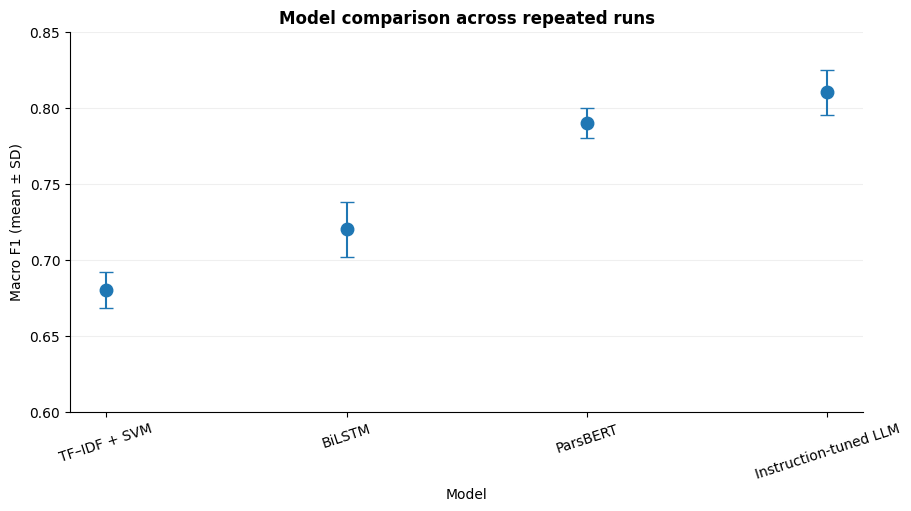

In [6]:
model_results = pd.DataFrame({
    "model": ["TF–IDF + SVM", "BiLSTM", "ParsBERT", "Instruction-tuned LLM"],
    "macro_f1": [0.68, 0.72, 0.79, 0.81],
    "std": [0.012, 0.018, 0.010, 0.015],
})

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
ax.errorbar(
    model_results["model"],
    model_results["macro_f1"],
    yerr=model_results["std"],
    fmt="o",
    capsize=5,
    markersize=9,
)
ax.set(
    title="Model comparison across repeated runs",
    xlabel="Model",
    ylabel="Macro F1 (mean ± SD)",
    ylim=(0.60, 0.85),
)
ax.tick_params(axis="x", rotation=18)
ax.grid(axis="y", alpha=0.2)
plt.show()

Error bars must be defined precisely: standard deviation, standard error, confidence interval, or another quantity.  
Do not infer statistical significance from overlap alone.

## 6. Paired-run differences

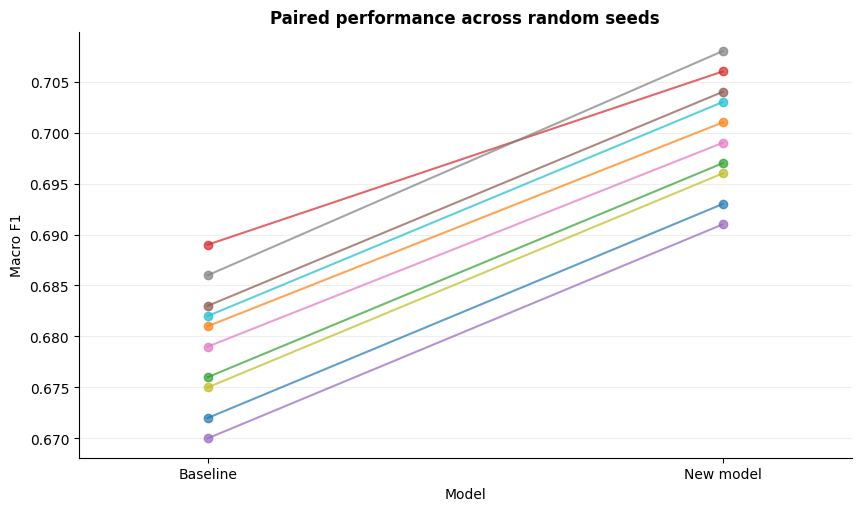

In [7]:
runs = np.arange(1, 11)
baseline = np.array([.672, .681, .676, .689, .670, .683, .679, .686, .675, .682])
new_model = np.array([.693, .701, .697, .706, .691, .704, .699, .708, .696, .703])

fig, ax = plt.subplots(layout="constrained")
for run, old, new in zip(runs, baseline, new_model):
    ax.plot([0, 1], [old, new], marker="o", alpha=0.7)

ax.set(
    title="Paired performance across random seeds",
    xlabel="Model",
    ylabel="Macro F1",
    xticks=[0, 1],
    xticklabels=["Baseline", "New model"],
    xlim=(-0.25, 1.25),
)
ax.grid(axis="y", alpha=0.2)
plt.show()

A paired plot shows whether an improvement is consistent across the same folds, seeds, or test subsets.

## 7. Learning curves

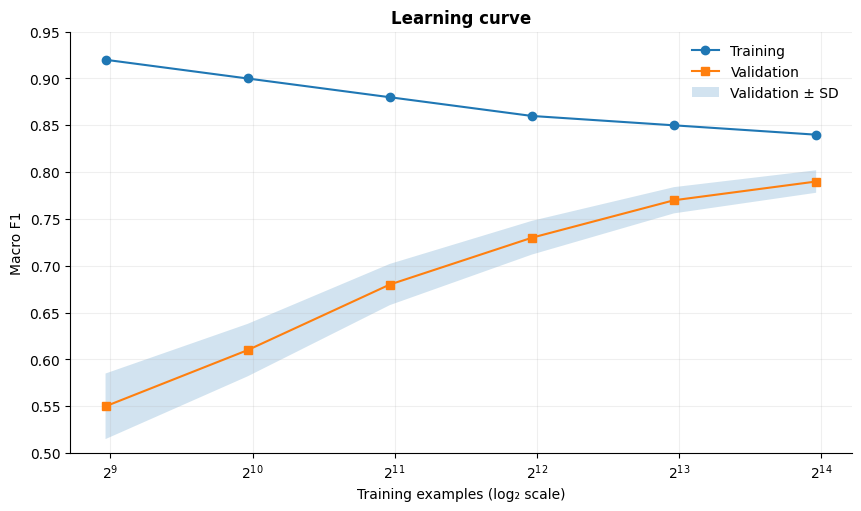

In [8]:
train_sizes = np.array([500, 1000, 2000, 4000, 8000, 16000])
train_score = np.array([0.92, 0.90, 0.88, 0.86, 0.85, 0.84])
valid_score = np.array([0.55, 0.61, 0.68, 0.73, 0.77, 0.79])
valid_sd = np.array([0.035, 0.028, 0.022, 0.018, 0.014, 0.012])

fig, ax = plt.subplots(layout="constrained")
ax.plot(train_sizes, train_score, marker="o", label="Training")
ax.plot(train_sizes, valid_score, marker="s", label="Validation")
ax.fill_between(
    train_sizes,
    valid_score - valid_sd,
    valid_score + valid_sd,
    alpha=0.2,
    label="Validation ± SD",
)
ax.set_xscale("log", base=2)
ax.set(
    title="Learning curve",
    xlabel="Training examples (log₂ scale)",
    ylabel="Macro F1",
    ylim=(0.5, 0.95),
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

Learning curves help distinguish data limitation from model limitation and can inform annotation-budget decisions.

## 8. Threshold trade-offs

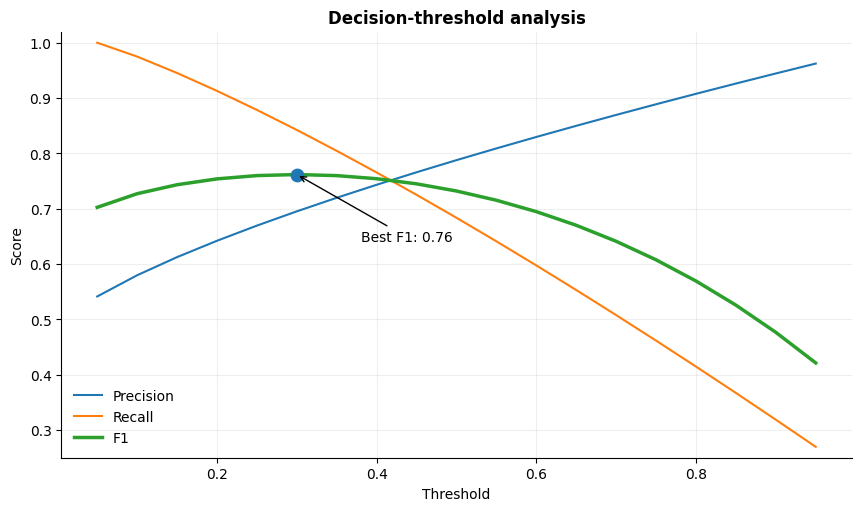

In [9]:
threshold = np.linspace(0.05, 0.95, 19)
precision = 0.48 + 0.50 * threshold**0.7
recall = 1.02 - 0.80 * threshold**1.25
precision = np.clip(precision, 0, 1)
recall = np.clip(recall, 0, 1)
f1 = 2 * precision * recall / (precision + recall)
best_idx = np.argmax(f1)

fig, ax = plt.subplots(layout="constrained")
ax.plot(threshold, precision, label="Precision")
ax.plot(threshold, recall, label="Recall")
ax.plot(threshold, f1, linewidth=2.5, label="F1")
ax.scatter(threshold[best_idx], f1[best_idx], s=80, zorder=3)
ax.annotate(
    f"Best F1: {f1[best_idx]:.2f}",
    xy=(threshold[best_idx], f1[best_idx]),
    xytext=(threshold[best_idx] + .08, f1[best_idx] - .12),
    arrowprops={"arrowstyle": "->"},
)
ax.set(
    title="Decision-threshold analysis",
    xlabel="Threshold",
    ylabel="Score",
    ylim=(0.25, 1.02),
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 9. Calibration plot

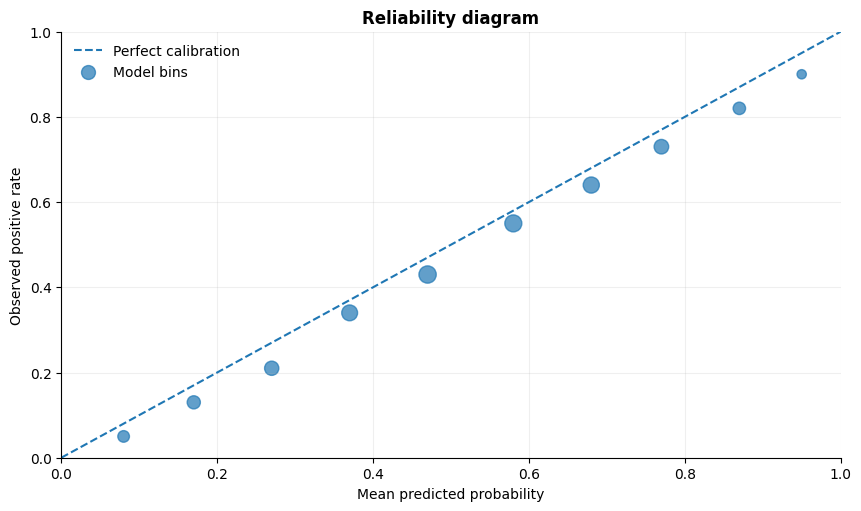

In [10]:
predicted_probability = np.array([.08, .17, .27, .37, .47, .58, .68, .77, .87, .95])
observed_frequency = np.array([.05, .13, .21, .34, .43, .55, .64, .73, .82, .90])
bin_size = np.array([140, 180, 210, 260, 310, 300, 270, 220, 160, 90])

fig, ax = plt.subplots(layout="constrained")
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.scatter(
    predicted_probability,
    observed_frequency,
    s=bin_size / 2,
    alpha=0.7,
    label="Model bins",
)
ax.set(
    title="Reliability diagram",
    xlabel="Mean predicted probability",
    ylabel="Observed positive rate",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

Marker area encodes the number of examples in each probability bin.  
Calibration quality is different from ranking or classification quality.

## 10. Semantic-relatedness predictions

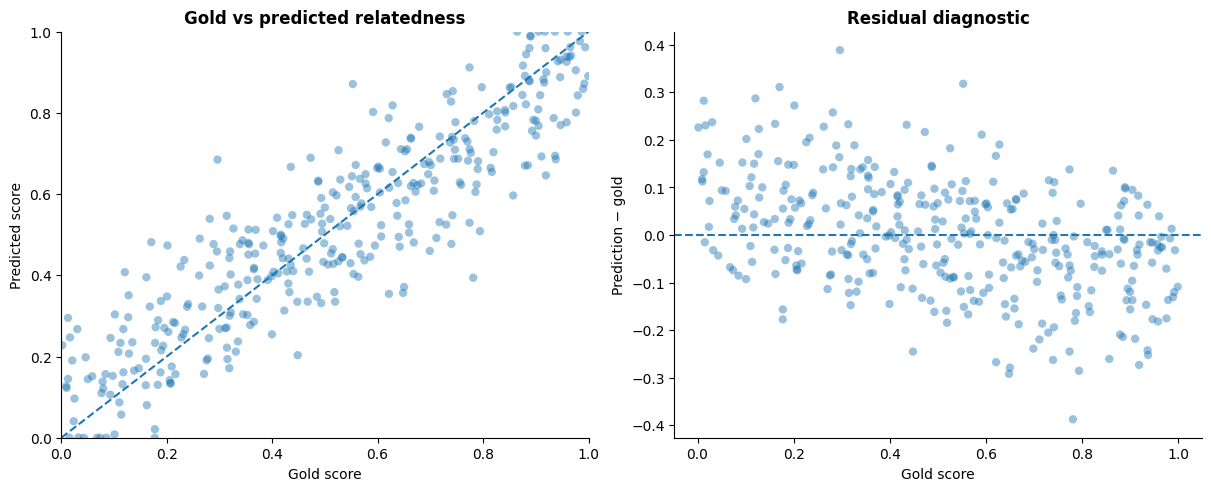

In [11]:
gold = RNG.uniform(0, 1, 350)
pred = np.clip(0.08 + 0.84 * gold + RNG.normal(0, 0.11, len(gold)), 0, 1)
residual = pred - gold

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")

axes[0].scatter(gold, pred, alpha=0.45, edgecolors="none")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set(
    title="Gold vs predicted relatedness",
    xlabel="Gold score",
    ylabel="Predicted score",
    xlim=(0, 1),
    ylim=(0, 1),
)

axes[1].scatter(gold, residual, alpha=0.45, edgecolors="none")
axes[1].axhline(0, linestyle="--")
axes[1].set(
    title="Residual diagnostic",
    xlabel="Gold score",
    ylabel="Prediction − gold",
)
plt.show()

The identity line shows perfect predictions. The residual panel can reveal systematic over- or under-prediction across the score range.

## 11. Error slices

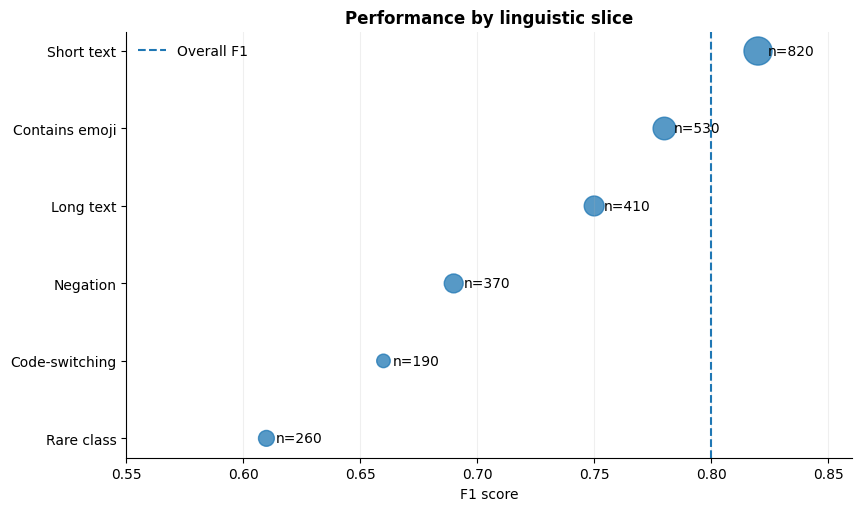

In [12]:
slices = pd.DataFrame({
    "slice": ["Short text", "Long text", "Contains emoji", "Code-switching", "Rare class", "Negation"],
    "n": [820, 410, 530, 190, 260, 370],
    "f1": [.82, .75, .78, .66, .61, .69],
}).sort_values("f1")

fig, ax = plt.subplots(layout="constrained")
points = ax.scatter(slices["f1"], slices["slice"], s=slices["n"] / 2, alpha=0.75)
ax.axvline(.80, linestyle="--", label="Overall F1")
for _, row in slices.iterrows():
    ax.annotate(f"n={int(row['n'])}", (row["f1"], row["slice"]), xytext=(7, 0),
                textcoords="offset points", va="center")
ax.set(
    title="Performance by linguistic slice",
    xlabel="F1 score",
    ylabel="",
    xlim=(0.55, 0.86),
)
ax.legend()
ax.grid(axis="x", alpha=0.2)
plt.show()

Slice analysis is especially useful for phenomena such as negation, code-switching, figurative language, spelling variation, or low-resource classes.

## 12. A 2-D embedding projection

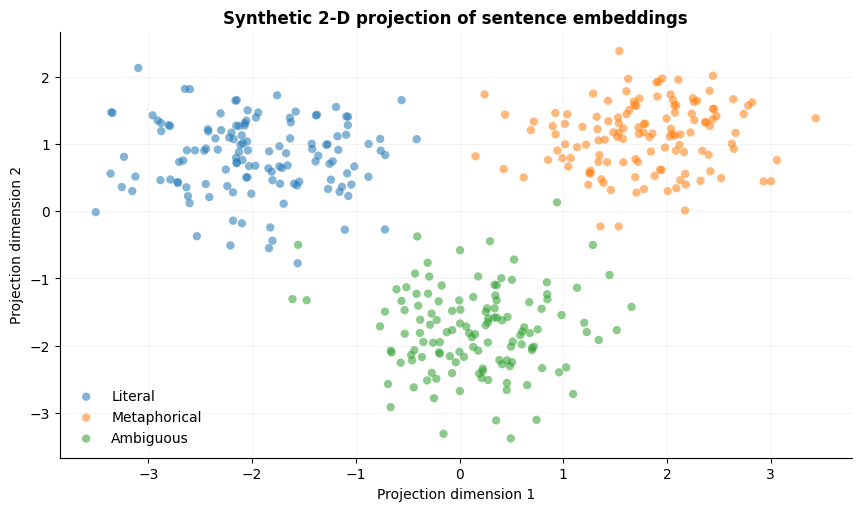

In [13]:
centers = np.array([[-2.0, 0.8], [1.8, 1.2], [0.2, -1.7]])
names = ["Literal", "Metaphorical", "Ambiguous"]
points = []
point_labels = []

for idx, center in enumerate(centers):
    cluster = RNG.normal(center, [0.65, 0.55], size=(130, 2))
    points.append(cluster)
    point_labels.extend([idx] * len(cluster))

points = np.vstack(points)
point_labels = np.array(point_labels)

fig, ax = plt.subplots(layout="constrained")
for idx, name in enumerate(names):
    mask = point_labels == idx
    ax.scatter(points[mask, 0], points[mask, 1], alpha=0.55, label=name, edgecolors="none")

ax.set(
    title="Synthetic 2-D projection of sentence embeddings",
    xlabel="Projection dimension 1",
    ylabel="Projection dimension 2",
)
ax.legend()
ax.grid(alpha=0.15)
plt.show()

A projection such as PCA, t-SNE, or UMAP is a lossy 2-D view. Cluster appearance is not direct proof of separability or semantic structure.

## 13. Publication-quality multi-panel figure

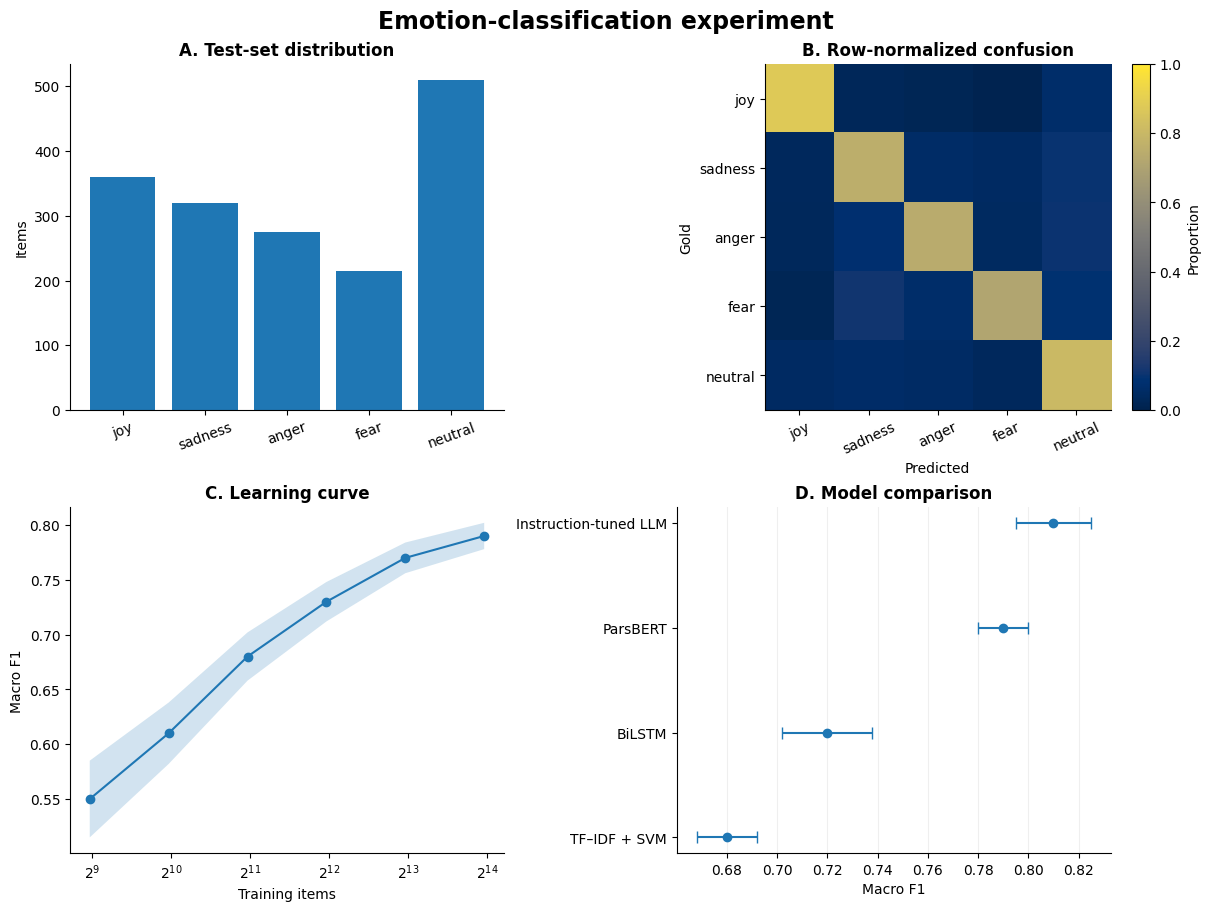

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), layout="constrained")

# A: class distribution
class_counts = np.array([360, 320, 275, 215, 509])
axes[0, 0].bar(class_names, class_counts)
axes[0, 0].set(title="A. Test-set distribution", ylabel="Items")
axes[0, 0].tick_params(axis="x", rotation=20)

# B: confusion matrix
norm_cm = cm / cm.sum(axis=1, keepdims=True)
im = axes[0, 1].imshow(norm_cm, cmap="cividis", vmin=0, vmax=1)
axes[0, 1].set(
    title="B. Row-normalized confusion",
    xlabel="Predicted",
    ylabel="Gold",
    xticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticks=np.arange(len(class_names)),
    yticklabels=class_names,
)
axes[0, 1].tick_params(axis="x", rotation=25)
fig.colorbar(im, ax=axes[0, 1], label="Proportion")

# C: learning curve
axes[1, 0].plot(train_sizes, valid_score, marker="o")
axes[1, 0].fill_between(train_sizes, valid_score-valid_sd, valid_score+valid_sd, alpha=.2)
axes[1, 0].set_xscale("log", base=2)
axes[1, 0].set(title="C. Learning curve", xlabel="Training items", ylabel="Macro F1")

# D: model comparison
axes[1, 1].errorbar(
    model_results["macro_f1"],
    model_results["model"],
    xerr=model_results["std"],
    fmt="o",
    capsize=4,
)
axes[1, 1].set(title="D. Model comparison", xlabel="Macro F1", ylabel="")
axes[1, 1].grid(axis="x", alpha=.2)

fig.suptitle("Emotion-classification experiment", fontsize=17, fontweight="bold")
plt.show()

## 14. Exporting a figure bundle

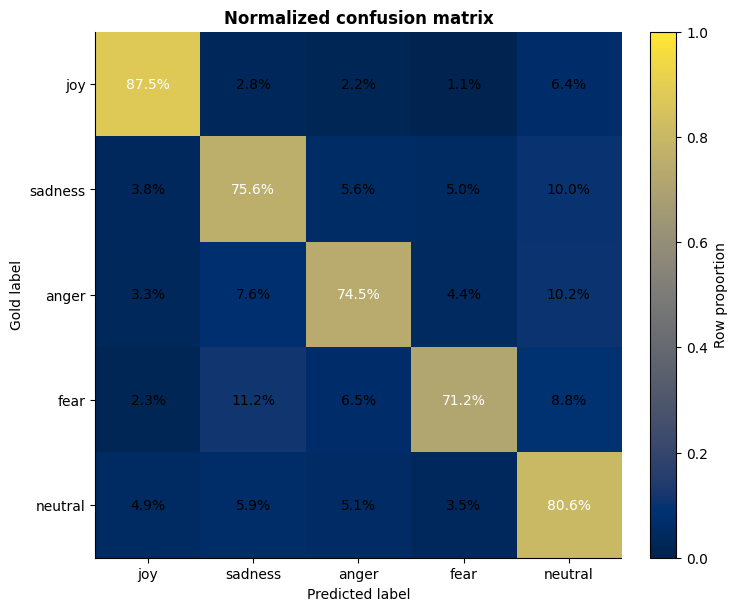

Exported figure bundle to: /mnt/data/04_matplotlib/figures


In [15]:
output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

fig, ax = plot_confusion_matrix(cm, class_names, normalize=True)
fig.savefig(output_dir / "emotion_confusion_matrix.png", dpi=300, bbox_inches="tight")
fig.savefig(output_dir / "emotion_confusion_matrix.svg", bbox_inches="tight")
fig.savefig(output_dir / "emotion_confusion_matrix.pdf", bbox_inches="tight")
plt.show()

print("Exported figure bundle to:", output_dir.resolve())

## 15. Research-figure checklist

Before publishing a plot:

- Define every metric, averaging method, and error bar.
- State the sample unit and sample size.
- Identify whether values come from one run, folds, seeds, or bootstrap samples.
- Label normalization direction in confusion matrices.
- Use consistent class orders across all figures.
- Avoid truncated bar axes unless there is a compelling and explicit reason.
- Use readable font sizes at the final printed width.
- Prefer vector output for papers when feasible.
- Keep synthetic examples separate from real experimental results.
- Save plotting code and the exact data used to generate each figure.

## 16. Exercises

1. Replace the synthetic confusion matrix with a six-class emotion matrix and plot both counts and row-normalized values.
2. Compare three systems using macro-F1 means and standard deviations from five random seeds.
3. Build a learning curve and mark the point after which gains become smaller than one percentage point.
4. Plot performance by error slice for negation, code-switching, metaphor, spelling variation, and long texts.
5. For a semantic-relatedness model, plot gold scores against predictions and add a residual panel.
6. Produce a four-panel appendix figure and export it as PNG, SVG, and PDF.


## 17. Reference solutions

These examples emphasize transparent uncertainty, consistent scales, and publication-safe export.


### Solution 1 — count and normalized confusion matrices


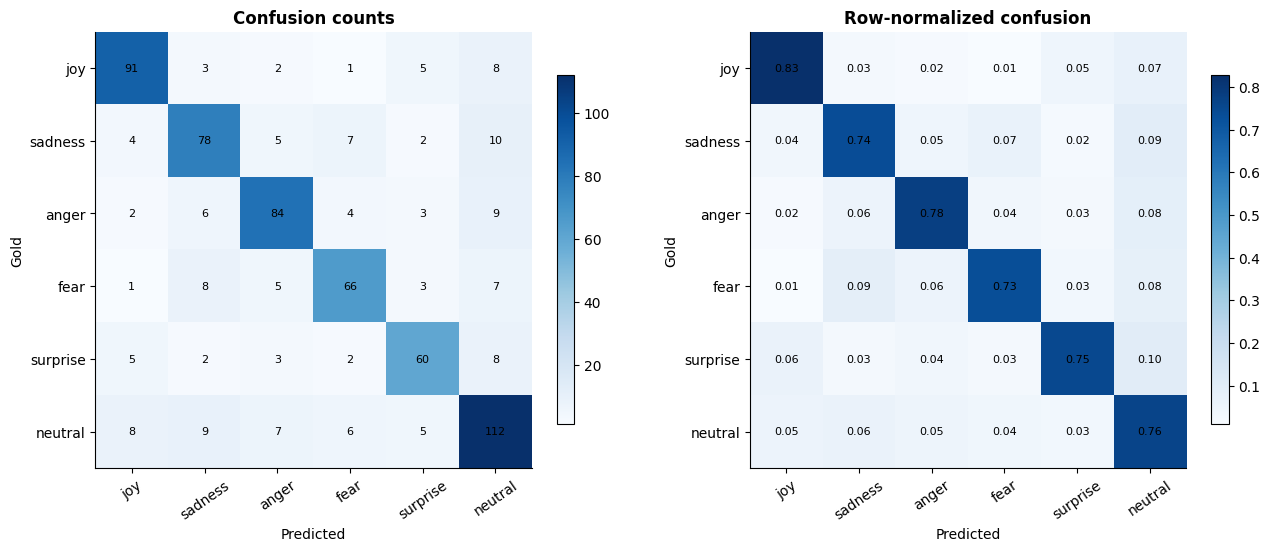

In [16]:
six_labels = ["joy", "sadness", "anger", "fear", "surprise", "neutral"]
cm_six = np.array([
    [91, 3, 2, 1, 5, 8],
    [4, 78, 5, 7, 2, 10],
    [2, 6, 84, 4, 3, 9],
    [1, 8, 5, 66, 3, 7],
    [5, 2, 3, 2, 60, 8],
    [8, 9, 7, 6, 5, 112],
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), layout="constrained")
for ax, values, title, fmt in [
    (axes[0], cm_six, "Confusion counts", "d"),
    (axes[1], cm_six / cm_six.sum(axis=1, keepdims=True), "Row-normalized confusion", ".2f"),
]:
    im = ax.imshow(values, cmap="Blues")
    ax.set(title=title, xlabel="Predicted", ylabel="Gold",
           xticks=np.arange(len(six_labels)), xticklabels=six_labels,
           yticks=np.arange(len(six_labels)), yticklabels=six_labels)
    ax.tick_params(axis="x", rotation=35)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, format(values[i, j], fmt), ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()


### Solution 2 — model means and seed variability


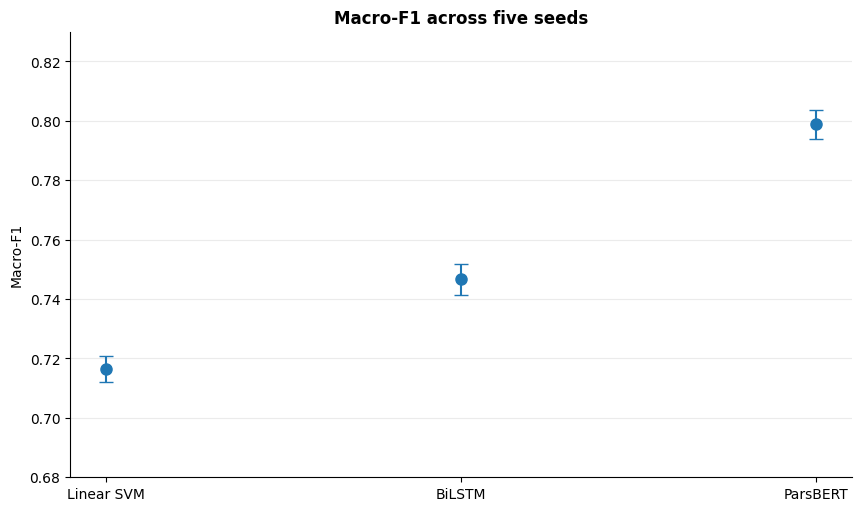

In [17]:
seed_scores = pd.DataFrame({
    "Linear SVM": [0.711, 0.719, 0.714, 0.722, 0.716],
    "BiLSTM": [0.744, 0.752, 0.748, 0.739, 0.750],
    "ParsBERT": [0.792, 0.801, 0.797, 0.805, 0.799],
})
means = seed_scores.mean()
stds = seed_scores.std(ddof=1)

fig, ax = plt.subplots(layout="constrained")
ax.errorbar(means.index, means.values, yerr=stds.values, fmt="o", capsize=5, markersize=8)
ax.set(title="Macro-F1 across five seeds", ylabel="Macro-F1", ylim=(0.68, 0.83))
ax.grid(axis="y", alpha=0.25)
plt.show()


### Solution 3 — diminishing returns on a learning curve


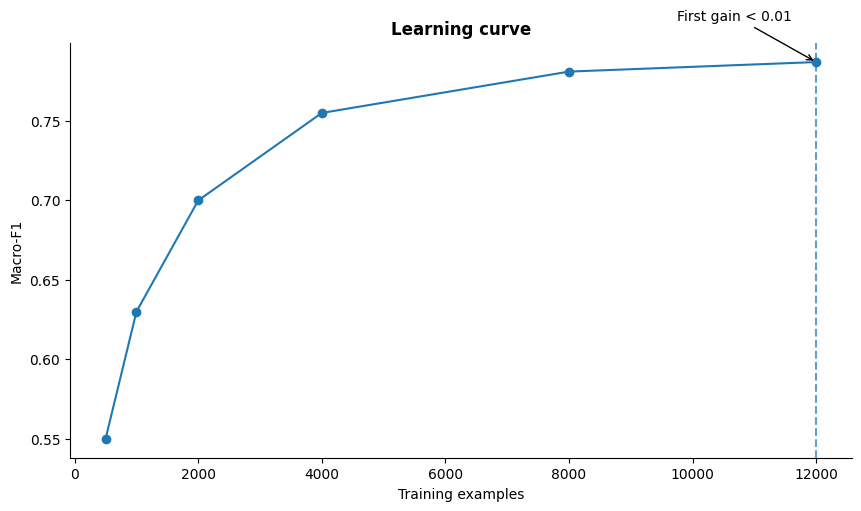

In [18]:
train_sizes = np.array([500, 1_000, 2_000, 4_000, 8_000, 12_000])
macro_f1 = np.array([0.55, 0.63, 0.70, 0.755, 0.781, 0.787])
gains = np.diff(macro_f1)
small_gain_positions = np.where(gains < 0.01)[0]
plateau_i = small_gain_positions[0] + 1 if len(small_gain_positions) else len(train_sizes) - 1

fig, ax = plt.subplots(layout="constrained")
ax.plot(train_sizes, macro_f1, marker="o")
ax.axvline(train_sizes[plateau_i], linestyle="--", alpha=0.7)
ax.annotate(
    "First gain < 0.01",
    xy=(train_sizes[plateau_i], macro_f1[plateau_i]),
    xytext=(-100, 30), textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
)
ax.set(title="Learning curve", xlabel="Training examples", ylabel="Macro-F1")
plt.show()


### Solution 4 — error-slice comparison


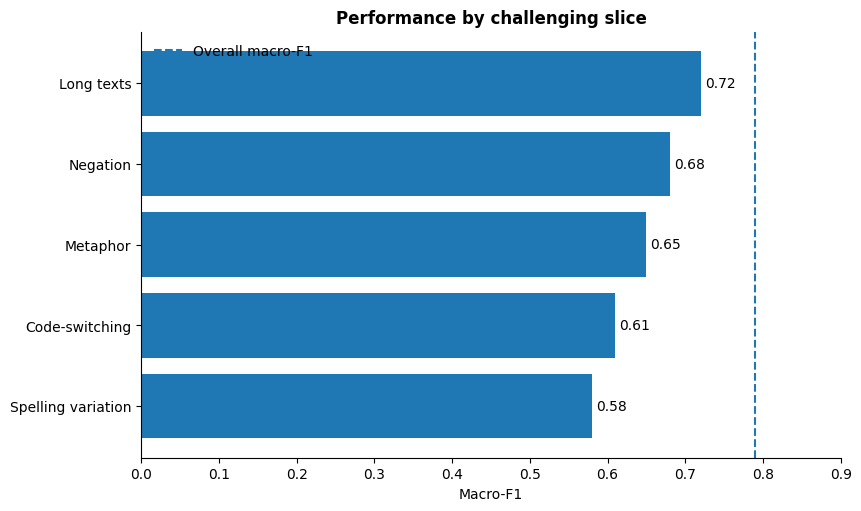

In [19]:
slice_scores_solution = pd.Series({
    "Negation": 0.68,
    "Code-switching": 0.61,
    "Metaphor": 0.65,
    "Spelling variation": 0.58,
    "Long texts": 0.72,
}).sort_values()

fig, ax = plt.subplots(layout="constrained")
bars = ax.barh(slice_scores_solution.index, slice_scores_solution.values)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.axvline(0.79, linestyle="--", label="Overall macro-F1")
ax.set(title="Performance by challenging slice", xlabel="Macro-F1", xlim=(0, 0.9))
ax.legend()
plt.show()


### Solution 5 — predictions and residuals


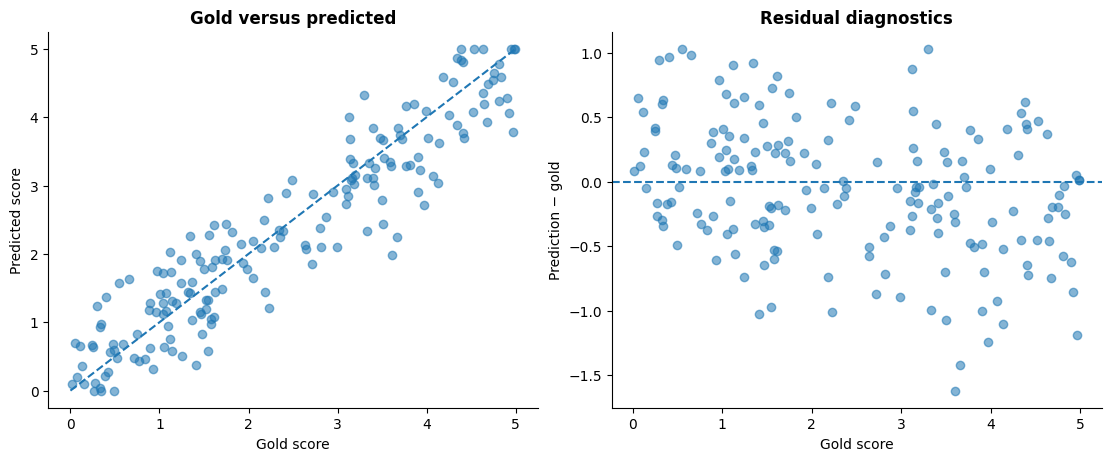

In [20]:
gold_solution = RNG.uniform(0, 5, 180)
pred_solution = np.clip(0.25 + 0.88 * gold_solution + RNG.normal(0, 0.48, 180), 0, 5)
residual_solution = pred_solution - gold_solution

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
axes[0].scatter(gold_solution, pred_solution, alpha=0.55)
axes[0].plot([0, 5], [0, 5], linestyle="--")
axes[0].set(title="Gold versus predicted", xlabel="Gold score", ylabel="Predicted score")
axes[1].scatter(gold_solution, residual_solution, alpha=0.55)
axes[1].axhline(0, linestyle="--")
axes[1].set(title="Residual diagnostics", xlabel="Gold score", ylabel="Prediction − gold")
plt.show()


### Solution 6 — publication appendix and export


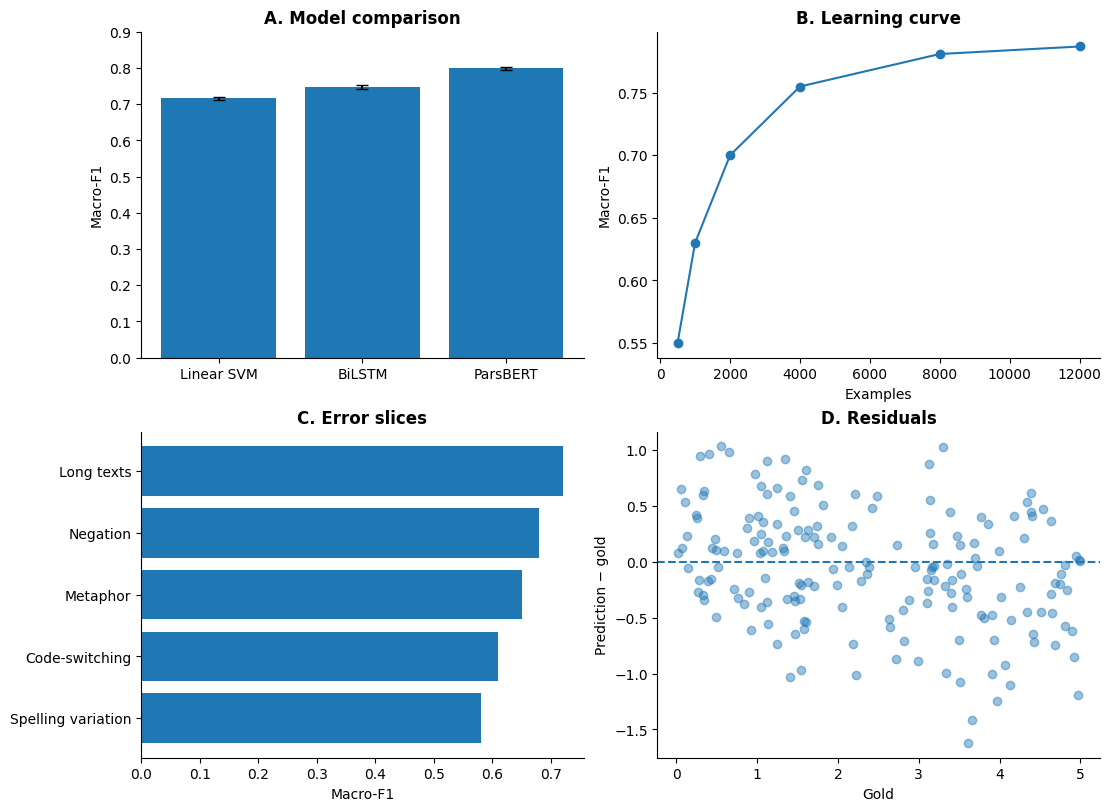

Exported appendix to: /mnt/data/04_matplotlib/figures/appendix_solution


In [21]:
appendix_dir = Path("figures/appendix_solution")
appendix_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), layout="constrained")
axes[0, 0].bar(means.index, means.values, yerr=stds.values, capsize=4)
axes[0, 0].set(title="A. Model comparison", ylabel="Macro-F1", ylim=(0, 0.9))
axes[0, 1].plot(train_sizes, macro_f1, marker="o")
axes[0, 1].set(title="B. Learning curve", xlabel="Examples", ylabel="Macro-F1")
axes[1, 0].barh(slice_scores_solution.index, slice_scores_solution.values)
axes[1, 0].set(title="C. Error slices", xlabel="Macro-F1")
axes[1, 1].scatter(gold_solution, residual_solution, alpha=0.45)
axes[1, 1].axhline(0, linestyle="--")
axes[1, 1].set(title="D. Residuals", xlabel="Gold", ylabel="Prediction − gold")

for suffix, kwargs in {
    "png": {"dpi": 300},
    "svg": {},
    "pdf": {},
}.items():
    fig.savefig(appendix_dir / f"nlp_appendix.{suffix}", bbox_inches="tight", **kwargs)
plt.show()

print("Exported appendix to:", appendix_dir.resolve())


## 18. References

- Matplotlib quick start: https://matplotlib.org/stable/users/explain/quick_start.html
- Annotated heatmaps: https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
- Error bars: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html
- Fill between: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html
- Saving figures: https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html
